In [34]:
! pip install numpy
! pip install pandas
! pip install -U scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Linear Regression and Cross-Validation
by AI@UCI

** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT WITH THE REQUIRED PACKAGES **

## 1. Representing Non-Linear Relationships with Linear Regression

Linear regression can model **non-linear relationships** by transforming the input features. The key insight is that we apply linear regression to transformed features rather than the original features.

For example, instead of modeling:
- `y = θ₀ + θ₁x`

We can model:
- `y = θ₀ + θ₁x + θ₂x² + θ₃x³ + ...`

This is still **linear in the parameters** (θ), which is what makes it linear regression.


In [36]:
df = pd.read_csv("../datasets/nonlinear_data_pt1.csv")

X = np.array(df['X'])
y = df['y']
y_true = df['y_true']
X_original = X.reshape(-1, 1)

In [37]:
lr_simple = LinearRegression()
lr_simple.fit(X_original, y)
y_pred_simple = lr_simple.predict(X_original)

# Create polynomial features
poly_features = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_features.fit_transform(X_original)

# Fit linear regression on transformed features
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)
y_pred_poly = lr_poly.predict(X_poly)

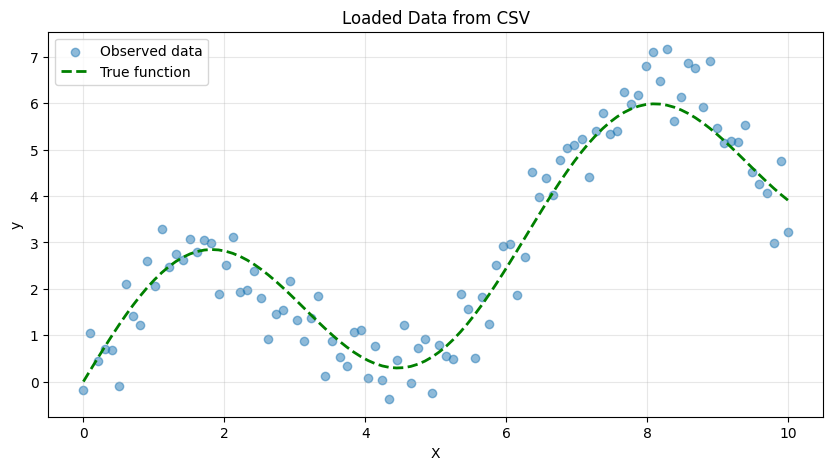

In [38]:
# Visualize our data
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.5, label='Observed data')
plt.plot(X, y_true, 'g--', linewidth=2, label='True function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Loaded Data from CSV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [39]:
lr_simple = LinearRegression()
lr_simple.fit(X_original, y)
y_pred_simple = lr_simple.predict(X_original)

# Create polynomial features
poly_features = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_features.fit_transform(X_original)

# Fit linear regression on transformed features
lr_poly = LinearRegression() # This the equations that follows y = ax^2 + bx + c; still linear in features [a, b, c]
lr_poly.fit(X_poly, y)
y_pred_poly = lr_poly.predict(X_poly)


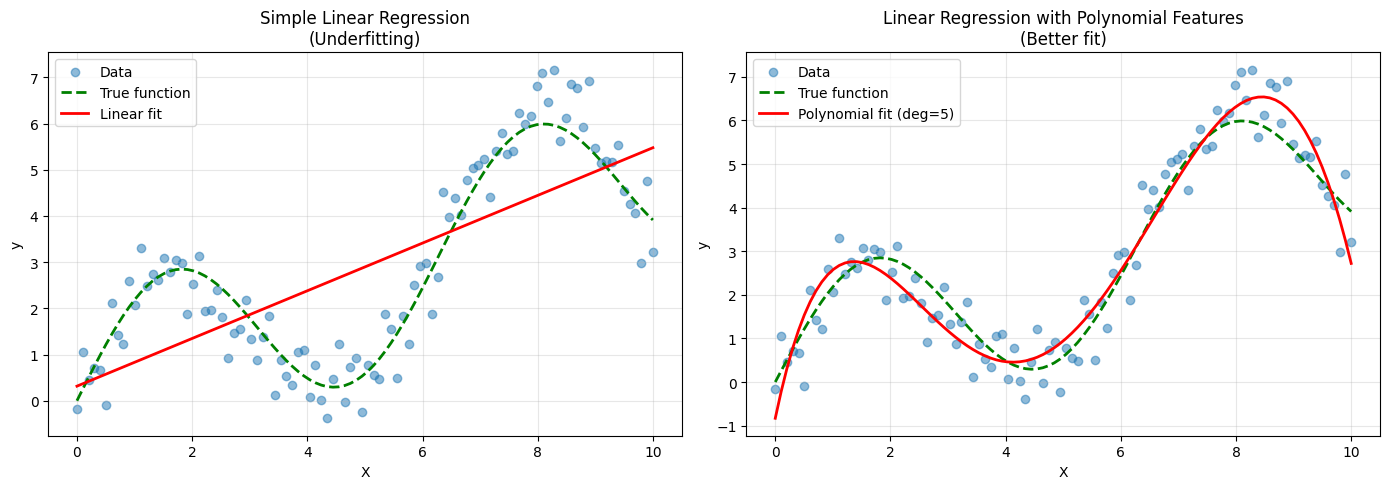

Simple Linear R squared Score: 0.50
Polynomial Features R squared Score: 0.93


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple linear regression
axes[0].scatter(X, y, alpha=0.5, label='Data')
axes[0].plot(X, y_true, 'g--', linewidth=2, label='True function')
axes[0].plot(X, y_pred_simple, 'r-', linewidth=2, label='Linear fit')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Simple Linear Regression\n(Underfitting)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Polynomial regression
axes[1].scatter(X, y, alpha=0.5, label='Data')
axes[1].plot(X, y_true, 'g--', linewidth=2, label='True function')
axes[1].plot(X, y_pred_poly, 'r-', linewidth=2, label='Polynomial fit (deg=5)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Linear Regression with Polynomial Features\n(Better fit)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Simple Linear R squared Score: {r2_score(y, y_pred_simple):.2f}")
print(f"Polynomial Features R squared Score: {r2_score(y, y_pred_poly):.2f}")

### Key Insight
**Linear regression can model non-linear relationships by transforming features!** The model is still linear in its parameters, but can capture complex patterns.

# 2. Hyperplane in Transformed Space

This is one of the most important insights in machine learning:

1. **In the transformed feature space**, we fit a **linear hyperplane**
2. **When projected back to the original space**, this hyperplane becomes a **non-linear curve**

This is how linear methods can produce non-linear predictions!


In [41]:
# For visualization, let's use degree 2 polynomial (easier to visualize)
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_2.fit_transform(X_original)
# Features are now: [x, x²]

lr_2 = LinearRegression()
lr_2.fit(X_poly_2, y)
y_pred_2 = lr_2.predict(X_poly_2)

print(f"Original feature space: 1D (just x)")
print(f"Transformed feature space: 2D (x and x²)")
print(f"\nLinear model in transformed space:")
print(f"y = {lr_2.intercept_:.3f} + {lr_2.coef_[0]:.3f}*x + {lr_2.coef_[1]:.3f}*x²")

Original feature space: 1D (just x)
Transformed feature space: 2D (x and x²)

Linear model in transformed space:
y = 1.545 + -0.229*x + 0.075*x²


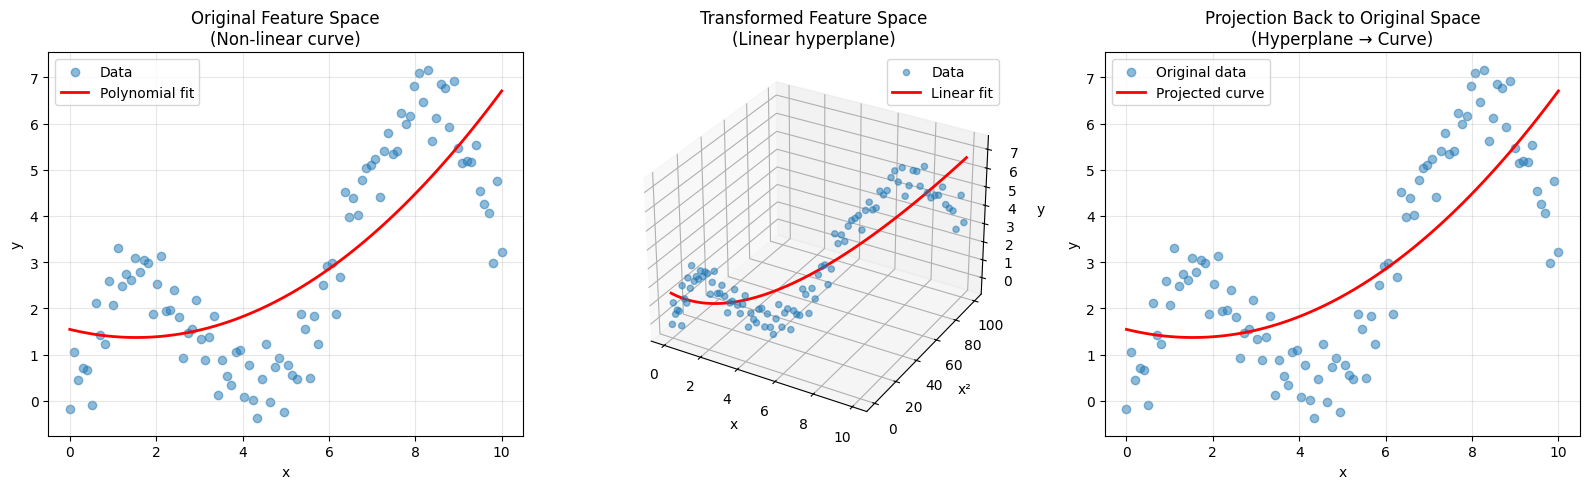

In [42]:
# Visualize in Both Spaces
fig = plt.figure(figsize=(16, 5))

# Original space
ax1 = fig.add_subplot(131)
ax1.scatter(X, y, alpha=0.5, label='Data')
ax1.plot(X, y_pred_2, 'r-', linewidth=2, label='Polynomial fit')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original Feature Space\n(Non-linear curve)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Transformed space (3D view)
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_poly_2[:, 0], X_poly_2[:, 1], y, alpha=0.5, label='Data')
ax2.plot(X_poly_2[:, 0], X_poly_2[:, 1], y_pred_2, 'r-', linewidth=2, label='Linear fit')
ax2.set_xlabel('x')
ax2.set_ylabel('x²')
ax2.set_zlabel('y')
ax2.set_title('Transformed Feature Space\n(Linear hyperplane)')
ax2.legend()

# Show the projection concept
ax3 = fig.add_subplot(133)
ax3.scatter(X, y, alpha=0.5, label='Original data')
ax3.plot(X, y_pred_2, 'r-', linewidth=2, label='Projected curve')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Projection Back to Original Space\n(Hyperplane → Curve)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

- **In the transformed space** (x, x²), we fit a **linear hyperplane**
- **When we project** this hyperplane back to original space, it becomes a **curve**
- This is how linear regression models non-linear relationships!

# 3. Model Selection with K-Fold Cross-Validation

### Why Cross-Validation?

When we have many model choices (different polynomial degrees), how do we select the best one?

**K-Fold Cross-Validation:**
1. Split data into K equal parts (folds)
2. Train on K-1 folds, test on the remaining fold
3. Repeat K times, each time using a different fold as the test set
4. Average the performance across all K runs

This gives us a robust estimate of how well each model will generalize to new data.

In [43]:
# Read full dataset from CSV
df_full = pd.read_csv('../datasets/nonlinear_data_pt3.csv')


# Extract features and target
X_full = df_full['X'].values.reshape(-1, 1)
y_full = df_full['y'].values

In [44]:
# Compare different polynomial degrees
# Define models to compare
degrees = [1, 2, 3, 5, 7, 10, 15]
k_folds = 5

print(f"Comparing polynomial degrees: {degrees}")
print(f"Using {k_folds}-fold cross-validation\n")

# Store results
cv_means = []
cv_stds = []

for degree in degrees:
    # Create pipeline
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    
    # Perform k-fold cross-validation
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_full, y_full, 
                            cv=kfold, 
                            scoring='neg_mean_squared_error')
    
    # Convert to MSE (scores are negative)
    mse_scores = -scores
    cv_means.append(np.mean(mse_scores))
    cv_stds.append(np.std(mse_scores))
    
    print(f"Degree {degree:2d}: MSE = {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")

# Find best degree
best_idx = np.argmin(cv_means)
best_degree = degrees[best_idx]
print(f"\n✓ Best model: Polynomial degree {best_degree}")

Comparing polynomial degrees: [1, 2, 3, 5, 7, 10, 15]
Using 5-fold cross-validation

Degree  1: MSE = 2.1872 ± 0.3073
Degree  2: MSE = 1.9108 ± 0.3522
Degree  3: MSE = 1.8087 ± 0.3911
Degree  5: MSE = 0.4100 ± 0.0901
Degree  7: MSE = 0.2601 ± 0.0393
Degree 10: MSE = 0.2543 ± 0.0265
Degree 15: MSE = 0.4400 ± 0.0857

✓ Best model: Polynomial degree 10


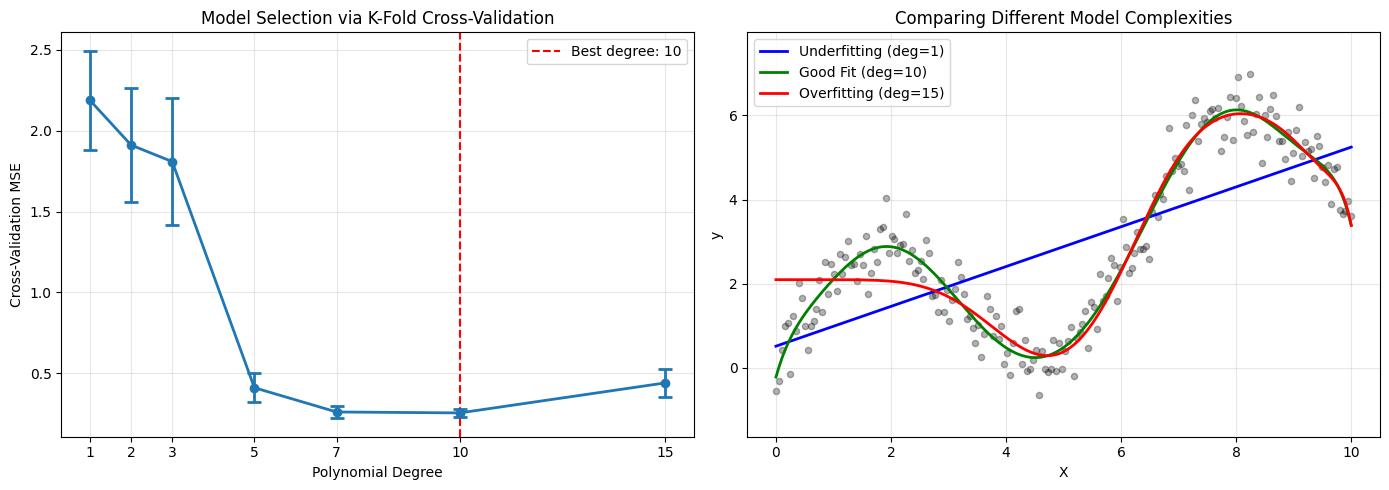

In [45]:
# Visualize Cross-Validation Results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV scores vs degree
axes[0].errorbar(degrees, cv_means, yerr=cv_stds, 
                marker='o', capsize=5, capthick=2, linewidth=2)
axes[0].axvline(best_degree, color='r', linestyle='--', 
               label=f'Best degree: {best_degree}')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Cross-Validation MSE')
axes[0].set_title('Model Selection via K-Fold Cross-Validation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees)

# Compare underfitting, good fit, and overfitting
test_degrees = [1, best_degree, 15]
colors = ['blue', 'green', 'red']
labels = ['Underfitting', 'Good Fit', 'Overfitting']

X_dense = np.linspace(0, 10, 300).reshape(-1, 1)

for deg, color, label in zip(test_degrees, colors, labels):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('linear', LinearRegression())
    ])
    model.fit(X_full, y_full)
    y_pred = model.predict(X_dense)
    axes[1].plot(X_dense, y_pred, color=color, linewidth=2, label=f'{label} (deg={deg})')

axes[1].scatter(X_full, y_full, alpha=0.3, color='black', s=20)
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Comparing Different Model Complexities')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([y_full.min()-1, y_full.max()+1])

plt.tight_layout()
plt.show()

### Understanding the Bias-Variance Tradeoff

- **Degree too low (e.g., 1)**: Underfitting - model is too simple
- **Degree just right**: Good balance - captures the pattern without excessive noise
- **Degree too high (e.g., 15)**: Overfitting - model fits noise in training data


# 4. Regularization with Cross-Validation

### Why Regularization?

High-degree polynomials can overfit. **Regularization** adds a penalty for large coefficients, encouraging simpler models.

**Ridge Regression:** Adds L2 penalty: `Loss = MSE + α * Σ(βᵢ²)`

The strength of regularization is controlled by hyperparameter **α** (alpha):
- Small α: Less regularization (more complex model)
- Large α: More regularization (simpler model)

In [46]:
# Compare different regularization strengths
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
degree = 10  # Use high degree to see regularization effect

print(f"Comparing Ridge regularization strengths for degree {degree} polynomial")
print(f"Alpha values: {alphas}\n")

ridge_means = []
ridge_stds = []

for alpha in alphas:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('ridge', Ridge(alpha=alpha))
    ])
    
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_full, y_full, 
                            cv=kfold, 
                            scoring='neg_mean_squared_error')
    
    mse_scores = -scores
    ridge_means.append(np.mean(mse_scores))
    ridge_stds.append(np.std(mse_scores))
    
    print(f"Alpha {alpha:7.3f}: MSE = {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")

best_alpha_idx = np.argmin(ridge_means)
best_alpha = alphas[best_alpha_idx]
print(f"\n✓ Best regularization: Alpha = {best_alpha}")

Comparing Ridge regularization strengths for degree 10 polynomial
Alpha values: [0.001, 0.01, 0.1, 1, 10, 100]

Alpha   0.001: MSE = 0.2538 ± 0.0258
Alpha   0.010: MSE = 0.2533 ± 0.0258
Alpha   0.100: MSE = 0.2532 ± 0.0260
Alpha   1.000: MSE = 0.2583 ± 0.0211
Alpha  10.000: MSE = 0.2962 ± 0.0341
Alpha 100.000: MSE = 0.3580 ± 0.0840

✓ Best regularization: Alpha = 0.1


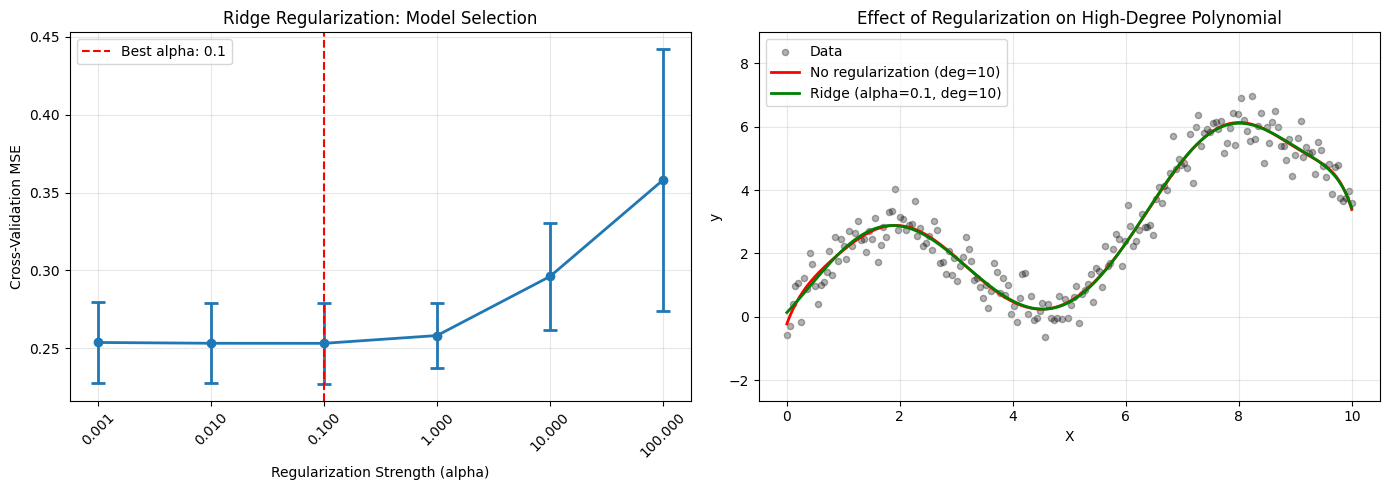

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV scores vs alpha
axes[0].errorbar(range(len(alphas)), ridge_means, yerr=ridge_stds,
                marker='o', capsize=5, capthick=2, linewidth=2)
axes[0].axvline(best_alpha_idx, color='r', linestyle='--',
               label=f'Best alpha: {best_alpha}')
axes[0].set_xlabel('Regularization Strength (alpha)')
axes[0].set_ylabel('Cross-Validation MSE')
axes[0].set_title('Ridge Regularization: Model Selection')
axes[0].set_xticks(range(len(alphas)))
axes[0].set_xticklabels([f'{a:.3f}' for a in alphas], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare no regularization vs best regularization
X_dense = np.linspace(0, 10, 300).reshape(-1, 1)

# No regularization
model_no_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('linear', LinearRegression())
])
model_no_reg.fit(X_full, y_full)
y_pred_no_reg = model_no_reg.predict(X_dense)

# Best regularization
model_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('ridge', Ridge(alpha=best_alpha))
])
model_reg.fit(X_full, y_full)
y_pred_reg = model_reg.predict(X_dense)

axes[1].scatter(X_full, y_full, alpha=0.3, color='black', s=20, label='Data')
axes[1].plot(X_dense, y_pred_no_reg, 'r-', linewidth=2, 
            label=f'No regularization (deg={degree})')
axes[1].plot(X_dense, y_pred_reg, 'g-', linewidth=2,
            label=f'Ridge (alpha={best_alpha}, deg={degree})')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Effect of Regularization on High-Degree Polynomial')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([y_full.min()-2, y_full.max()+2])

plt.tight_layout()
plt.show()

### Key Insight

Regularization helps prevent overfitting by penalizing complex models. Use cross-validation to find the optimal regularization strength!


## Summary and Key Takeaways

### 1. Feature Transformations
- Linear regression can model **non-linear relationships** through feature engineering
- **Polynomial features**: x → [x, x², x³, ...]
- Still using **linear** regression, just with transformed features!

### 2. Hyperplane Projection
- In the **transformed space**, we fit a linear hyperplane
- This hyperplane is **linear** in the transformed coordinates
- When **projected back** to original space, it becomes a **non-linear curve**
- **Key insight**: Linearity in one space = non-linearity in another

### 3. K-Fold Cross-Validation
- Essential for selecting **model complexity** (e.g., polynomial degree)
- Prevents **overfitting** by testing on held-out data
- Typical choices: **k=5 or k=10**
- Select model with **lowest average cross-validation error**

### 4. Regularization
- **Ridge/Lasso** help prevent overfitting with high-degree polynomials
- Regularization strength **(α)** is a hyperparameter to tune
- Use **cross-validation** to select optimal α
- **Larger α** = more regularization = simpler model

## Best Practices

✓ **Always use cross-validation** for model selection  
✓ **Consider both** model complexity AND regularization  
✓ **Visualize your results** to understand model behavior  
✓ **Balance** the bias-variance tradeoff  
✓ **Start simple**, then increase complexity as needed  
✓ **Use pipelines** to organize transformation + model steps